# 1.1 Face Dataset Exploratory Data Analysis

Dataset: Annotated Facial Images for Stroke Classification

Purpose:
- Count images
- Inspect class balance
- Check image readability
- Analyze image sizes
- Identify preprocessing issues

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import FACE_DATA_DIR, FIGURES_DIR
from rural_stroke_assist.preprocessing.image import (
    list_image_files,
    get_image_size,
    is_image_readable,
    infer_class_from_path,
)
from rural_stroke_assist.plots import save_bar_plot, save_histogram

In [2]:
image_paths = list_image_files(FACE_DATA_DIR)

print(f"Total image files found: {len(image_paths)}")
image_paths[:5]

Total image files found: 3749


[WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/face_stroke_images/Annotated stroke and non stroke Dataset/NonStroke/img_0022.jpg'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/face_stroke_images/Annotated stroke and non stroke Dataset/NonStroke/img_0024.jpg'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/face_stroke_images/Annotated stroke and non stroke Dataset/NonStroke/img_0025.jpg'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/face_stroke_images/Annotated stroke and non stroke Dataset/NonStroke/img_0027.jpg'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/face_stroke_images/Annotated stroke and non stroke Dataset/NonStroke/img_0030.jpg')]

In [3]:
records = []

for path in image_paths:
    readable = is_image_readable(path)

    if readable:
        width, height = get_image_size(path)
    else:
        width, height = None, None

    records.append(
        {
            "path": str(path),
            "file_name": path.name,
            "class_label": infer_class_from_path(path),
            "extension": path.suffix.lower(),
            "readable": readable,
            "width": width,
            "height": height,
        }
    )

face_df = pd.DataFrame(records)
face_df.head()

,path,file_name,class_label,extension,readable,width,height
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0022.jpg,NonStroke,.jpg,True,299,169
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0024.jpg,NonStroke,.jpg,True,379,379
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0025.jpg,NonStroke,.jpg,True,275,183
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0027.jpg,NonStroke,.jpg,True,163,222
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0030.jpg,NonStroke,.jpg,True,342,382


In [4]:
face_df.shape

(3749, 7)

In [5]:
class_counts = face_df["class_label"].value_counts()
class_percentages = face_df["class_label"].value_counts(normalize=True) * 100

class_balance_df = pd.DataFrame(
    {
        "count": class_counts,
        "percentage": class_percentages.round(2),
    }
)

class_balance_df

,count,percentage
class_label,,
NonStroke,2500,66.68
Stroke,1249,33.32


In [6]:
save_bar_plot(
    series=class_counts,
    title="Face Dataset Class Distribution",
    xlabel="Class",
    ylabel="Number of Images",
    output_path=FIGURES_DIR / "face_class_distribution.png",
)

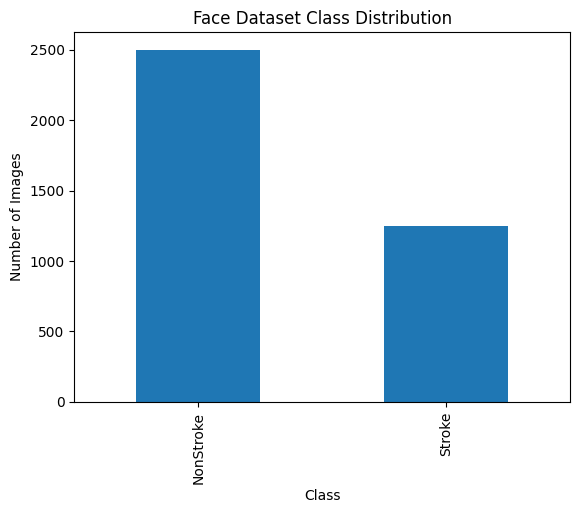

In [7]:
class_counts.plot(kind="bar", title="Face Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [8]:
readability_counts = face_df["readable"].value_counts()
readability_counts

readable
True    3749
Name: count, dtype: int64

In [9]:
unreadable_images = face_df[face_df["readable"] == False]
unreadable_images

,path,file_name,class_label,extension,readable,width,height


In [10]:
face_df[["width", "height"]].describe()

,width,height
count,3749.000000,3749.000000
mean,276.464124,285.479328
std,102.444368,116.923254
min,88.000000,86.000000
25%,213.000000,190.000000
50%,265.000000,262.000000
75%,300.000000,331.000000
max,766.000000,600.000000


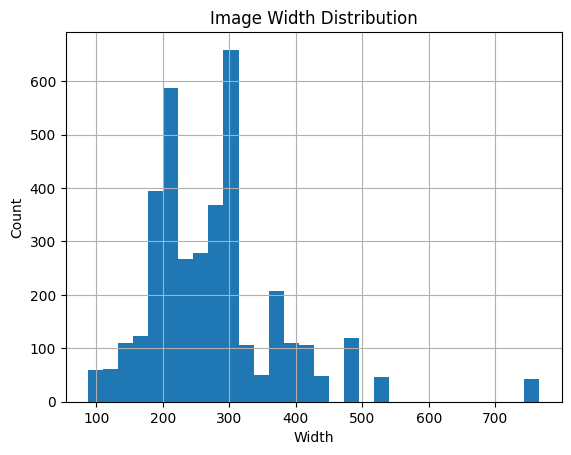

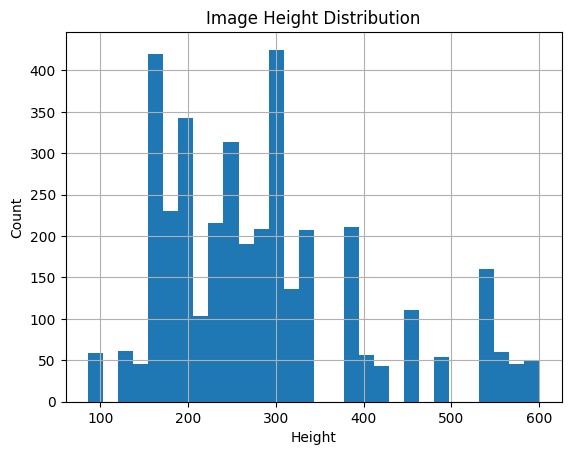

In [11]:
face_df["width"].hist(bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

face_df["height"].hist(bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

In [12]:
from rural_stroke_assist.config import FACE_IMAGE_MANIFEST_PATH

# Ensure the parent directory (interim/) exists
FACE_IMAGE_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save the DataFrame
face_df.to_csv(FACE_IMAGE_MANIFEST_PATH, index=False)

print(f"Saved manifest to: {FACE_IMAGE_MANIFEST_PATH}")

Saved manifest to: C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\interim\face_image_manifest.csv


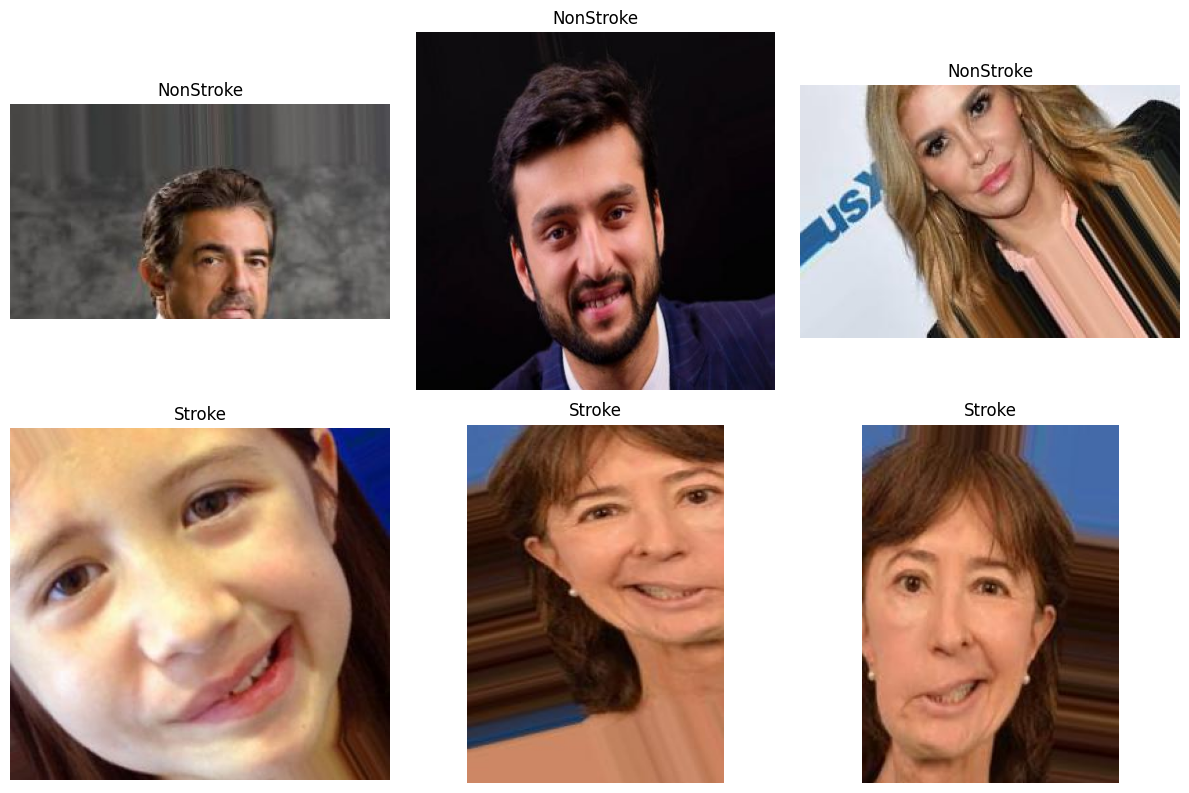

In [13]:
sample_df = face_df.groupby("class_label").head(3)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    image = Image.open(row["path"])

    plt.subplot(2, 3, i)
    plt.imshow(image)
    plt.title(row["class_label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Face Dataset Preprocessing Issues

Observed preprocessing issues:

1. Class imbalance  
   The dataset contains more non-stroke images than stroke images, which may bias a classifier toward the majority class.

2. Image size variation  
   Images may have different widths and heights, so resizing will be required before model training.

3. Face localization  
   Images may contain different backgrounds, crops, and face positions. Face detection or alignment may be needed.

4. Lighting and quality variation  
   Images may differ in brightness, sharpness, and compression quality.

5. Clinical validity limitation  
   The dataset is useful for prototyping a face-analysis module, but it should not be treated as sufficient for clinical validation.

6. Privacy and sourcing concern  
   Since the data is public and image-based, the final report should discuss dataset limitations and avoid overclaiming.